# Unidad 4 · Una máquina: reglas de despacho y el MIP que las juzga

**Planta:** Conservas del Itata S.A.
**Datos:** `DatosClases/4_Secuenciamiento/itata_trabajos_1maq.csv` — 10 lotes
en el autoclave durante la semana focal
**Solver:** Gurobi

---

## Qué se decide aquí

Hay diez lotes esperando el autoclave y una sola máquina. No hay nada que
asignar: todos van al mismo recurso. Lo único que se decide es **el orden**.

La pregunta parece pequeña y no lo es, porque el orden que conviene depende
por completo de lo que se quiera medir. La planta despacha por fecha
comprometida y cree que eso "minimiza los atrasos". Este cuaderno muestra que
esa frase, tal como está escrita, no significa nada: hay al menos cuatro
medidas distintas de atraso y la regla que es óptima para una puede ser de las
peores para otra.

## La notación que hace falta antes de discutir

Un problema de secuenciamiento se nombra con tres campos, `α | β | γ`
(Graham et al., 1979):

| campo | qué dice | valores de esta unidad |
|---|---|---|
| **α** | el entorno de máquinas | `1` una máquina, `Pm` paralelas idénticas, `Rm` paralelas no relacionadas, `Fm` flow shop, `Jm` job shop |
| **β** | las restricciones | vacío, `r_j` liberaciones, `s_ij` cambios dependientes de la secuencia, `prmu` permutación, `prec` precedencias |
| **γ** | el objetivo | `Cmax`, `ΣCj`, `ΣwjCj`, `Lmax`, `ΣTj`, `ΣUj` |

Este cuaderno vive entero en `1 | | γ`, y lo que cambia de sección en sección
es **γ**. Las definiciones, con `C_j` el instante en que el lote `j` sale del
autoclave y `d_j` su fecha comprometida:

* `L_j = C_j − d_j` es la **desviación** (*lateness*): puede ser negativa si
  el lote sale antes de plazo.
* `T_j = max(0, L_j)` es la **tardanza** (*tardiness*): solo cuenta el atraso,
  adelantarse no compensa.
* `U_j = 1` si `L_j > 0`: solo cuenta **si** hubo atraso, no cuánto.

Que `Lmax`, `ΣTj` y `ΣUj` sean tres cosas distintas es el contenido del
cuaderno, no un tecnicismo.

## Un detalle que conviene ver de una vez

En `1 | | γ` sin liberaciones ni cambios, `Cmax = Σ p_j` **cualquiera sea el
orden**. El makespan es constante. Si alguien presenta un modelo que
"minimiza el makespan" en una máquina, ese modelo no está decidiendo nada.
Recién en el cuaderno 02, al aparecer `s_ij`, `Cmax` pasa a depender del orden.

## Cifras de referencia

| criterio | SPT | EDD | WSPT | Moore-H | óptimo |
|---|---|---|---|---|---|
| Σ Cj | **184,0** | 197,5 | 209,5 | 187,0 | **184,0** |
| Σ wjCj | 456,0 | 518,0 | **392,0** | 479,5 | **392,0** |
| Lmax | 15,5 | **11,5** | 17,5 | 22,5 | **11,5** |
| Σ Tj | 33,5 | 21,5 | 57,5 | 37,0 | **20,5** |
| Σ Uj | 3 | 3 | 5 | **2** | **2** |

La fila de `Σ Tj` es el punto del cuaderno: es la única en que **ninguna**
regla alcanza el óptimo.

In [1]:
import sys
import math
import time
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

from comun import datos, tabla, figura, resumen, verificar, estilo

estilo()

tr = pd.read_csv(datos("4_Secuenciamiento", "itata_trabajos_1maq.csv"))

J = list(tr.lote)
p = dict(zip(tr.lote, tr.p_h))      # tiempo de proceso (h)
d = dict(zip(tr.lote, tr.d_h))      # fecha comprometida (h)
w = dict(zip(tr.lote, tr.w))        # peso comercial
r = dict(zip(tr.lote, tr.r_h))      # liberación (h)

print(f"{len(J)} lotes · Σ p_j = {sum(p.values()):.1f} h "
      f"(= Cmax, constante, sea cual sea el orden)")
tr

10 lotes · Σ p_j = 44.5 h (= Cmax, constante, sea cual sea el orden)


,lote,p_h,r_h,d_h,w,familia
0,J01-TOM-480,6.5,0.0,14.0,3.0,TOM
1,J02-DUR-480,3.0,0.0,10.0,1.0,DUR
2,J03-POR-480,4.5,2.0,21.0,4.0,POR
3,J04-TOM-3000,8.0,0.0,30.0,2.0,TOM
4,J05-DUR-820,2.5,6.0,12.0,5.0,DUR
5,J06-POR-3000,5.5,3.0,27.0,1.0,POR
6,J07-TOM-480,1.5,0.0,8.0,2.0,TOM
7,J08-DUR-480,7.0,1.0,33.0,3.0,DUR
8,J09-POR-480,2.0,10.0,19.0,6.0,POR
9,J10-TOM-3000,4.0,5.0,24.0,1.0,TOM


## 1. Evaluar una secuencia

Antes de cualquier regla y de cualquier modelo hace falta **una sola**
definición de cada métrica. Si cada sección calcula la tardanza a su manera,
la comparación final no compara nada.

La función recorre la secuencia acumulando tiempo y devuelve los seis
criterios de golpe. Es deliberadamente aburrida: es la referencia contra la
que se va a contrastar el solver.

In [2]:
def evaluar(sec):
    """Todas las métricas clásicas de una secuencia en una máquina."""
    t, C = 0.0, {}
    for j in sec:
        t += p[j]
        C[j] = t
    L = {j: C[j] - d[j] for j in sec}
    T = {j: max(0.0, L[j]) for j in sec}
    return {
        "Cmax": max(C.values()),
        "sumC": sum(C.values()),
        "sumwC": sum(w[j] * C[j] for j in sec),
        "Lmax": max(L.values()),
        "sumT": sum(T.values()),
        "sumU": sum(1 for j in sec if L[j] > 1e-9),
        "C": C,
    }


demo = evaluar(J)
print("Secuencia tal como viene el archivo:")
print("  " + " ".join(x[:3] for x in J))
for k in ("Cmax", "sumC", "sumwC", "Lmax", "sumT", "sumU"):
    print(f"  {k:6s} = {demo[k]:8.2f}")

Secuencia tal como viene el archivo:
  J01 J02 J03 J04 J05 J06 J07 J08 J09 J10
  Cmax   =    44.50
  sumC   =   261.50
  sumwC  =   747.50
  Lmax   =    23.50
  sumT   =    86.50
  sumU   =     6.00


## 2. Las reglas de despacho

Una regla de despacho ordena los trabajos con un criterio local y barato. No
resuelve un problema de optimización: ordena una lista. Y aun así **cuatro de
ellas son demostrablemente óptimas**, cada una para su criterio:

| regla | ordena por | óptima para | quién |
|---|---|---|---|
| **SPT** | `p_j` creciente | `1‖ΣCj` | intercambio adyacente |
| **WSPT** | `p_j / w_j` creciente | `1‖ΣwjCj` | Smith (1956) |
| **EDD** | `d_j` creciente | `1‖Lmax` | Jackson (1955) |
| **Moore-Hodgson** | ver abajo | `1‖ΣUj` | Moore (1968) |

Las otras tres son la práctica, no un teorema:

* **LPT** (`p_j` decreciente) es lo peor posible para `ΣCj` y sin embargo es
  una buena heurística en máquinas paralelas (cuaderno 03).
* **FCFS** (por `r_j`) es lo que hace la planta cuando nadie interviene.
* **CR** (razón crítica `(d_j − t)/p_j`) y **ATC** son **dinámicas**: se
  reevalúan después de cada trabajo, porque el índice depende del instante
  actual. Esa dependencia del tiempo es lo que las distingue de las estáticas.

El argumento de SPT en una línea, porque es el único que se puede hacer de
memoria: si dos trabajos adyacentes están en orden `i, j` con `p_i > p_j`,
intercambiarlos deja intactos todos los demás `C_k` y reduce la suma
`C_i + C_j`. Luego ninguna secuencia óptima tiene una inversión de SPT.

In [3]:
def spt():
    return sorted(J, key=lambda j: (p[j], j))


def lpt():
    return sorted(J, key=lambda j: (-p[j], j))


def edd():
    return sorted(J, key=lambda j: (d[j], j))


def wspt():
    return sorted(J, key=lambda j: (p[j] / w[j], j))


def fcfs():
    return sorted(J, key=lambda j: (r[j], j))


def critical_ratio():
    """Razón crítica (d_j - t) / p_j. Dinámica: se reevalúa tras cada lote."""
    pend, sec, t = list(J), [], 0.0
    while pend:
        j = min(pend, key=lambda z: ((d[z] - t) / p[z], z))
        sec.append(j)
        t += p[j]
        pend.remove(j)
    return sec


def atc(k=2.0):
    """Apparent Tardiness Cost (Rachamadugu-Morton).

    Interpola entre WSPT (cuando nada corre riesgo de atraso) y una regla de
    urgencia (cuando todo lo corre): k chico se parece a EDD, k grande a WSPT.
    Elegir k mirando los datos, y no copiándolo de un libro, es parte del
    ejercicio.
    """
    pend, sec, t = list(J), [], 0.0
    pbar = sum(p.values()) / len(J)
    while pend:
        def indice(z):
            holgura = max(0.0, d[z] - p[z] - t)
            return (w[z] / p[z]) * math.exp(-holgura / (k * pbar))
        j = max(pend, key=lambda z: (indice(z), -ord(z[0])))
        sec.append(j)
        t += p[j]
        pend.remove(j)
    return sec


for nombre, sec in [("SPT", spt()), ("EDD", edd()), ("WSPT", wspt()),
                    ("CR", critical_ratio()), ("ATC", atc())]:
    print(f"  {nombre:5s}  " + " ".join(x[:3] for x in sec))

  SPT    J07 J09 J05 J02 J10 J03 J06 J01 J08 J04
  EDD    J07 J02 J05 J01 J09 J03 J10 J06 J04 J08
  WSPT   J09 J05 J07 J03 J01 J08 J02 J04 J10 J06
  CR     J01 J07 J02 J05 J03 J09 J10 J06 J04 J08
  ATC    J05 J07 J09 J01 J03 J02 J10 J08 J04 J06


## 3. Moore-Hodgson: minimizar el *número* de atrasados

El algoritmo es corto y su lógica vale más que su código. Se recorren los
trabajos en orden EDD y se van aceptando. Cuando aceptar uno produce atraso,
se **descarta el más largo de los aceptados hasta ahí** —no el que causó el
problema—, porque descartar el más largo es lo que más tiempo libera para
todos los que vienen.

Los descartados se hacen al final, todos atrasados, en el orden que sea: ya
están perdidos para efectos de `ΣUj` y ordenarlos no cambia el objetivo.

Ahí está el costo escondido del algoritmo: para salvar a muchos **sacrifica
por completo a unos pocos**. Esos pocos acumulan una tardanza enorme, y por
eso `ΣTj` de Moore-Hodgson va a salir mal. No es un defecto de la
implementación: es exactamente lo que el objetivo `ΣUj` pide.

In [4]:
def moore_hodgson():
    S, t = [], 0.0
    for j in edd():
        S.append(j)
        t += p[j]
        if t > d[j] + 1e-9:
            k = max(S, key=lambda z: (p[z], z))   # el más largo de los aceptados
            S.remove(k)
            t -= p[k]
    en_plazo = sorted(S, key=lambda z: (d[z], z))
    tardios = [j for j in J if j not in S]
    return en_plazo + tardios, tardios


sec_mh, descartados = moore_hodgson()
print("Moore-Hodgson  " + " ".join(x[:3] for x in sec_mh))
print(f"\n  en plazo   : {len(sec_mh) - len(descartados)} lotes")
print(f"  sacrificados: {descartados}")
ev_mh = evaluar(sec_mh)
print(f"\n  Σ Uj = {ev_mh['sumU']}   pero   Σ Tj = {ev_mh['sumT']:.1f} h")
print("  Dos lotes concentran casi toda la tardanza. Eso es el algoritmo")
print("  funcionando como debe, no fallando.")

Moore-Hodgson  J07 J02 J05 J09 J03 J10 J06 J08 J01 J04

  en plazo   : 8 lotes
  sacrificados: ['J01-TOM-480', 'J04-TOM-3000']

  Σ Uj = 2   pero   Σ Tj = 37.0 h
  Dos lotes concentran casi toda la tardanza. Eso es el algoritmo
  funcionando como debe, no fallando.


## 4. La tabla regla × objetivo

Ocho secuencias, cinco criterios. Cada columna se lee **hacia abajo**: la
mejor regla de una columna suele no ser la mejor de la columna vecina.

In [5]:
REGLAS = {"SPT": spt(), "LPT": lpt(), "EDD": edd(), "WSPT": wspt(),
          "FCFS": fcfs(), "CR": critical_ratio(), "ATC": atc(),
          "Moore-H": sec_mh}

filas = []
for nombre, sec in REGLAS.items():
    e = evaluar(sec)
    filas.append({"regla": nombre, "sumC": e["sumC"], "sumwC": e["sumwC"],
                  "Lmax": e["Lmax"], "sumT": e["sumT"], "sumU": e["sumU"]})
reglas_df = pd.DataFrame(filas)
print(reglas_df.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

  regla  sumC  sumwC  Lmax  sumT  sumU
    SPT 184.0  456.0  15.5  33.5     3
    LPT 305.5  904.5  36.5 147.5     7
    EDD 197.5  518.0  11.5  21.5     3
   WSPT 209.5  392.0  17.5  57.5     5
   FCFS 272.0  857.5  30.5 101.5     6
     CR 212.5  568.0  11.5  25.0     6
    ATC 200.5  421.5  17.5  36.5     3
Moore-H 187.0  479.5  22.5  37.0     2


## 5. El MIP disyuntivo: un criterio a la vez

La formulación **disyuntiva** es la compacta para una máquina sin cambios de
secuencia. Una binaria por **par** de trabajos:

$$x_{ij} = 1 \iff i \text{ se procesa antes que } j$$

y para cada par, una de las dos restricciones se activa y la otra se relaja:

$$C_j \ge C_i + p_j - H(1 - x_{ij}), \qquad C_i \ge C_j + p_i - H\,x_{ij}$$

Con `H = Σ p_j`, que es el mayor `C_j` posible. Son `n(n−1)/2 = 45` binarias
para 10 lotes: el modelo es diminuto y el solver lo cierra en milisegundos.

Lo importante es que el modelo **no cambia** al cambiar de objetivo. Las
restricciones son las mismas cinco veces; lo único que se reescribe es la
función objetivo, y para `ΣTj` y `ΣUj` hay que agregar variables auxiliares:

* `T_j ≥ C_j − d_j`, `T_j ≥ 0` linealiza `max(0, ·)` **solo porque se está
  minimizando**: en un mínimo, `T_j` se pega a su cota inferior. Escribir lo
  mismo en un problema de maximización daría cualquier cosa.
* `C_j ≤ d_j + H·U_j` con `U_j` binaria fuerza `U_j = 1` cuando hay atraso.
  Esas 10 binarias extra son la razón de que `ΣUj` sea el objetivo más caro
  de los cinco.

In [6]:
H = sum(p.values())          # cota superior válida de cualquier C_j


def resolver(objetivo, tiempo_limite=60.0):
    m = gp.Model(f"1maq-{objetivo}")
    m.Params.OutputFlag = 0
    m.Params.TimeLimit = tiempo_limite
    m.Params.MIPGap = 1e-9

    C = m.addVars(J, lb=0.0, ub=H, name="C")
    pares = [(a, b) for i, a in enumerate(J) for b in J[i + 1:]]
    x = m.addVars(pares, vtype=GRB.BINARY, name="x")

    for j in J:
        m.addConstr(C[j] >= p[j], name=f"minimo[{j}]")
    for (a, b) in pares:
        m.addConstr(C[b] >= C[a] + p[b] - H * (1 - x[a, b]), name=f"disy1[{a},{b}]")
        m.addConstr(C[a] >= C[b] + p[a] - H * x[a, b], name=f"disy2[{a},{b}]")

    if objetivo == "sumC":
        expr = gp.quicksum(C[j] for j in J)
    elif objetivo == "sumwC":
        expr = gp.quicksum(w[j] * C[j] for j in J)
    elif objetivo == "Lmax":
        Lmax = m.addVar(lb=-GRB.INFINITY, name="Lmax")
        m.addConstrs((Lmax >= C[j] - d[j] for j in J), name="lmax")
        expr = Lmax
    elif objetivo == "sumT":
        T = m.addVars(J, lb=0.0, name="T")
        m.addConstrs((T[j] >= C[j] - d[j] for j in J), name="tardanza")
        expr = gp.quicksum(T[j] for j in J)
    elif objetivo == "sumU":
        U = m.addVars(J, vtype=GRB.BINARY, name="U")
        m.addConstrs((C[j] <= d[j] + H * U[j] for j in J), name="tardio")
        expr = gp.quicksum(U[j] for j in J)
    else:
        raise ValueError(objetivo)

    m.setObjective(expr, GRB.MINIMIZE)
    t0 = time.perf_counter()
    m.optimize()
    seg = time.perf_counter() - t0

    secuencia = sorted(J, key=lambda j: C[j].X)
    return {"objetivo": objetivo, "valor": m.ObjVal, "estado": _estado(m.Status),
            "gap_%": 100 * m.MIPGap, "vars": m.NumVars, "binarias": m.NumBinVars,
            "restr": m.NumConstrs, "seg": seg, "secuencia": secuencia}


def _estado(s):
    return {GRB.OPTIMAL: "OPTIMAL", GRB.TIME_LIMIT: "TIME_LIMIT",
            GRB.INFEASIBLE: "INFEASIBLE"}.get(s, f"STATUS_{s}")


CRITERIOS = ["sumC", "sumwC", "Lmax", "sumT", "sumU"]
optimos = {c: resolver(c) for c in CRITERIOS}

print("Modelo disyuntivo, un objetivo por corrida:\n")
print(f"{'objetivo':8s} {'valor':>9s} {'estado':>10s} {'gap %':>7s} "
      f"{'vars':>6s} {'binarias':>9s} {'restr':>7s} {'seg':>7s}")
for c in CRITERIOS:
    o = optimos[c]
    print(f"{c:8s} {o['valor']:9.2f} {o['estado']:>10s} {o['gap_%']:7.4f} "
          f"{o['vars']:6d} {o['binarias']:9d} {o['restr']:7d} {o['seg']:7.3f}")

print("\nSecuencias óptimas (una por criterio):")
for c in CRITERIOS:
    print(f"  {c:6s}  " + " ".join(x[:3] for x in optimos[c]["secuencia"]))

Restricted license - for non-production use only - expires 2027-11-29


Modelo disyuntivo, un objetivo por corrida:

objetivo     valor     estado   gap %   vars  binarias   restr     seg
sumC        184.00    OPTIMAL  0.0000     55        45     100  32.451
sumwC       392.00    OPTIMAL  0.0000     55        45     100   3.739
Lmax         11.50    OPTIMAL  0.0000     56        45     110   3.913
sumT         20.50    OPTIMAL  0.0000     65        45     110   2.862
sumU          2.00    OPTIMAL  0.0000     65        55     110   0.212

Secuencias óptimas (una por criterio):
  sumC    J07 J09 J05 J02 J10 J03 J06 J01 J08 J04
  sumwC   J09 J05 J07 J03 J01 J08 J02 J10 J04 J06
  Lmax    J02 J09 J07 J04 J01 J05 J10 J03 J06 J08
  sumT    J05 J02 J07 J01 J09 J03 J10 J06 J08 J04
  sumU    J05 J07 J02 J03 J09 J10 J06 J08 J01 J04


### Comprobación de que el solver no inventó nada

El valor que reporta Gurobi es el de *su* función objetivo. Que ese número
corresponda al calendario que efectivamente devuelve es una afirmación
distinta, y hay que verificarla recalculando la métrica desde la secuencia
con la misma función `evaluar` de la sección 1. Un modelo con un big-M mal
puesto o una desigualdad al revés puede reportar `OPTIMAL` y un valor que su
propio calendario no cumple.

In [7]:
print("Valor del solver vs. valor recalculado sobre su secuencia:\n")
for c in CRITERIOS:
    o = optimos[c]
    recalc = evaluar(o["secuencia"])[c]
    marca = "OK" if abs(recalc - o["valor"]) < 1e-6 else "DIFIERE"
    print(f"  {c:6s}  solver {o['valor']:8.2f}   calendario {recalc:8.2f}   [{marca}]")

Valor del solver vs. valor recalculado sobre su secuencia:

  sumC    solver   184.00   calendario   184.00   [OK]
  sumwC   solver   392.00   calendario   392.00   [OK]
  Lmax    solver    11.50   calendario    11.50   [OK]
  sumT    solver    20.50   calendario    20.50   [OK]
  sumU    solver     2.00   calendario     2.00   [OK]


## 6. Regla contra óptimo

Ahora la tabla completa, con el óptimo de cada criterio al final.

In [8]:
comparacion = reglas_df.copy()
fila_opt = {"regla": "ÓPTIMO (MIP)"}
for c in CRITERIOS:
    fila_opt[c] = optimos[c]["valor"]
comparacion = pd.concat([comparacion, pd.DataFrame([fila_opt])], ignore_index=True)
print(comparacion.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

print("\nExceso de cada regla sobre el óptimo de su criterio (%):\n")
exceso = comparacion[comparacion.regla != "ÓPTIMO (MIP)"].copy()
for c in CRITERIOS:
    z = optimos[c]["valor"]
    if c == "Lmax":
        # Lmax puede ser negativo: el porcentaje no significa nada. Se informa
        # la diferencia absoluta en horas y se dice que es en horas.
        exceso[c] = comparacion.loc[comparacion.regla != "ÓPTIMO (MIP)", c] - z
    else:
        exceso[c] = 100 * (comparacion.loc[comparacion.regla != "ÓPTIMO (MIP)", c] / z - 1)
exceso = exceso.rename(columns={"Lmax": "Lmax (dif. h)"})
print(exceso.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))

       regla  sumC  sumwC  Lmax  sumT  sumU
         SPT 184.0  456.0  15.5  33.5   3.0
         LPT 305.5  904.5  36.5 147.5   7.0
         EDD 197.5  518.0  11.5  21.5   3.0
        WSPT 209.5  392.0  17.5  57.5   5.0
        FCFS 272.0  857.5  30.5 101.5   6.0
          CR 212.5  568.0  11.5  25.0   6.0
         ATC 200.5  421.5  17.5  36.5   3.0
     Moore-H 187.0  479.5  22.5  37.0   2.0
ÓPTIMO (MIP) 184.0  392.0  11.5  20.5   2.0

Exceso de cada regla sobre el óptimo de su criterio (%):

  regla  sumC  sumwC  Lmax (dif. h)  sumT  sumU
    SPT   0.0   16.3            4.0  63.4  50.0
    LPT  66.0  130.7           25.0 619.5 250.0
    EDD   7.3   32.1            0.0   4.9  50.0
   WSPT  13.9    0.0            6.0 180.5 150.0
   FCFS  47.8  118.8           19.0 395.1 200.0
     CR  15.5   44.9            0.0  22.0 200.0
    ATC   9.0    7.5            6.0  78.0  50.0
Moore-H   1.6   22.3           11.0  80.5   0.0


### Lo que hay que leer en esa tabla

**1. Cada regla óptima lo es para su criterio y solo para ese.** SPT clava
`ΣCj = 184,0` y se va a `456,0` en `ΣwjCj`, un 16 % sobre el óptimo. WSPT
hace lo simétrico: perfecta en `ΣwjCj`, 14 % por encima en `ΣCj`. No hay
contradicción. SPT ignora los pesos, y en estos datos los lotes cortos no son
los valiosos: `J09-POR-480` dura 2 h y pesa 6, `J04-TOM-3000` dura 8 h y pesa
2. Ponderar cambia el orden.

**2. EDD resuelve `Lmax` y no resuelve `ΣTj`.** Esta es la fila que importa.
EDD da `Lmax = 11,5`, que es el óptimo, y da `ΣTj = 21,5` contra un óptimo de
`20,5`. Es poco, un 5 %, y precisamente por eso es instructivo: la diferencia
no es un error numérico ni una casualidad de los datos. `1‖Lmax` se resuelve
ordenando una lista; `1‖ΣTj` es **NP-difícil** (Du y Leung, 1990), y no se
conoce ninguna regla de despacho que lo resuelva. Que el peor caso sea 5 % en
esta instancia no dice nada del peor caso en otra.

**3. Moore-Hodgson gana `ΣUj` y pierde `ΣTj`.** Baja a 2 atrasados —contra 3
de SPT y de EDD— y su `ΣTj = 37,0` es 80 % peor que el óptimo, peor que SPT y
que EDD. Lo hace sacrificando enteramente dos lotes.

Ese último punto no es técnico. Minimizar el **número** de pedidos atrasados y
minimizar el atraso **total** son objetivos distintos y dan planes distintos.
Cuál se prefiere depende de cómo cobre la multa el cliente: si el contrato
penaliza por pedido incumplido, `ΣUj`; si penaliza por día de atraso, `ΣTj`.
Esa es una decisión comercial. El modelo puede resolver cualquiera de las
dos, pero no puede elegir cuál.

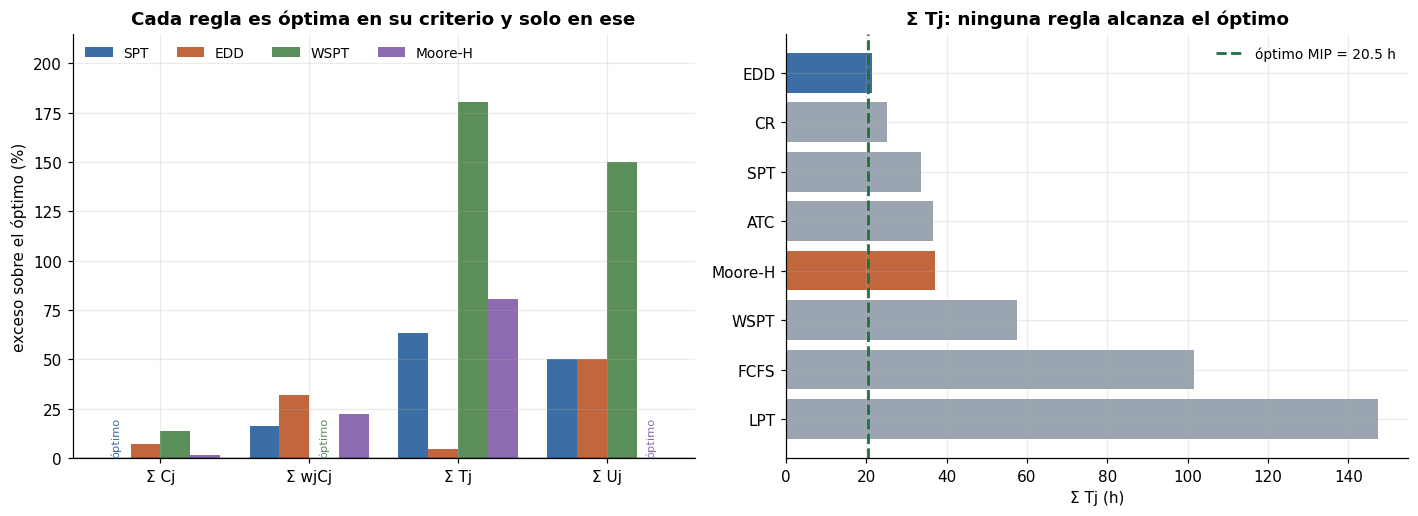

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

# --- panel izquierdo: exceso relativo de cada regla, por criterio
criterios_rel = ["sumC", "sumwC", "sumT", "sumU"]
etiquetas = {"sumC": "Σ Cj", "sumwC": "Σ wjCj", "sumT": "Σ Tj", "sumU": "Σ Uj"}
reglas_graf = ["SPT", "EDD", "WSPT", "Moore-H"]
ancho = 0.2
xs = np.arange(len(criterios_rel))
colores = ["#3b6ea5", "#c1663d", "#5a8f5a", "#8c6bb1"]

for k, rg in enumerate(reglas_graf):
    vals = []
    for c in criterios_rel:
        v = float(reglas_df.loc[reglas_df.regla == rg, c].iloc[0])
        vals.append(100 * (v / optimos[c]["valor"] - 1))
    barras = ax[0].bar(xs + (k - 1.5) * ancho, vals, ancho, label=rg,
                       color=colores[k])
    for b, v in zip(barras, vals):
        if v < 1e-9:
            ax[0].text(b.get_x() + b.get_width() / 2, 1.5, "óptimo",
                       ha="center", fontsize=7.5, rotation=90, color=colores[k])

ax[0].set_xticks(xs)
ax[0].set_xticklabels([etiquetas[c] for c in criterios_rel])
ax[0].set_ylabel("exceso sobre el óptimo (%)")
ax[0].set_title("Cada regla es óptima en su criterio y solo en ese")
ax[0].axhline(0, color="black", lw=0.9)
ax[0].set_ylim(0, 215)      # sitio para la leyenda sobre la barra más alta
ax[0].legend(ncol=4, fontsize=9, loc="upper left")

# --- panel derecho: la fila de Sigma Tj, la unica sin regla ganadora
vals_T = [float(reglas_df.loc[reglas_df.regla == rg, "sumT"].iloc[0])
          for rg in REGLAS]
orden = np.argsort(vals_T)
nombres = [list(REGLAS)[i] for i in orden]
valores = [vals_T[i] for i in orden]
cols = ["#c1663d" if n == "Moore-H" else ("#3b6ea5" if n == "EDD" else "#9aa5b1")
        for n in nombres]
ax[1].barh(nombres, valores, color=cols)
ax[1].axvline(optimos["sumT"]["valor"], color="#1f6f3d", lw=1.8, ls="--",
              label=f"óptimo MIP = {optimos['sumT']['valor']:.1f} h")
ax[1].invert_yaxis()
ax[1].set_xlabel("Σ Tj (h)")
ax[1].set_title("Σ Tj: ninguna regla alcanza el óptimo")
ax[1].legend(fontsize=9)

figura(fig, "reglas_vs_optimo")
plt.show()

## 7. El calendario del plan que la planta debería usar

Depende de qué firmó con el cliente. Se muestran los dos extremos del dilema:
el plan que minimiza `ΣUj` (Moore-Hodgson, óptimo) y el que minimiza `ΣTj`
(el MIP). Compararlos lote por lote es más elocuente que cualquier tabla
agregada.

In [10]:
def calendario(sec, etiqueta):
    t, filas = 0.0, []
    for orden, j in enumerate(sec, start=1):
        ini = t
        t += p[j]
        filas.append({"orden": orden, "lote": j, "inicio": ini, "fin": t,
                      "d_j": d[j], "L_j": t - d[j], "T_j": max(0.0, t - d[j]),
                      "atrasado": int(t > d[j] + 1e-9)})
    df = pd.DataFrame(filas)
    print(f"\n{etiqueta}")
    print(df.to_string(index=False, float_format=lambda v: f"{v:,.1f}"))
    print(f"  Σ Tj = {df.T_j.sum():.1f} h   ·   Σ Uj = {int(df.atrasado.sum())} lotes")
    return df


cal_mh = calendario(sec_mh, "Plan Moore-Hodgson (óptimo en Σ Uj)")
cal_T = calendario(optimos["sumT"]["secuencia"], "Plan MIP (óptimo en Σ Tj)")

print("\nEl primero deja 2 lotes atrasados y acumula 37,0 h de tardanza.")
print("El segundo acumula 20,5 h y deja más lotes fuera de plazo.")
print("Ninguno de los dos domina al otro: son puntos distintos de la frontera.")


Plan Moore-Hodgson (óptimo en Σ Uj)
 orden         lote  inicio  fin  d_j   L_j  T_j  atrasado
     1  J07-TOM-480     0.0  1.5  8.0  -6.5  0.0         0
     2  J02-DUR-480     1.5  4.5 10.0  -5.5  0.0         0
     3  J05-DUR-820     4.5  7.0 12.0  -5.0  0.0         0
     4  J09-POR-480     7.0  9.0 19.0 -10.0  0.0         0
     5  J03-POR-480     9.0 13.5 21.0  -7.5  0.0         0
     6 J10-TOM-3000    13.5 17.5 24.0  -6.5  0.0         0
     7 J06-POR-3000    17.5 23.0 27.0  -4.0  0.0         0
     8  J08-DUR-480    23.0 30.0 33.0  -3.0  0.0         0
     9  J01-TOM-480    30.0 36.5 14.0  22.5 22.5         1
    10 J04-TOM-3000    36.5 44.5 30.0  14.5 14.5         1
  Σ Tj = 37.0 h   ·   Σ Uj = 2 lotes

Plan MIP (óptimo en Σ Tj)
 orden         lote  inicio  fin  d_j  L_j  T_j  atrasado
     1  J05-DUR-820     0.0  2.5 12.0 -9.5  0.0         0
     2  J02-DUR-480     2.5  5.5 10.0 -4.5  0.0         0
     3  J07-TOM-480     5.5  7.0  8.0 -1.0  0.0         0
     4  J01-TOM-48

## 8. Comprobación

In [11]:
print("Comprobación:")
ok = []
ref_reglas = {
    ("SPT", "sumC"): 184.0, ("EDD", "sumC"): 197.5, ("WSPT", "sumC"): 209.5,
    ("Moore-H", "sumC"): 187.0,
    ("SPT", "sumwC"): 456.0, ("EDD", "sumwC"): 518.0, ("WSPT", "sumwC"): 392.0,
    ("Moore-H", "sumwC"): 479.5,
    ("SPT", "Lmax"): 15.5, ("EDD", "Lmax"): 11.5, ("WSPT", "Lmax"): 17.5,
    ("Moore-H", "Lmax"): 22.5,
    ("SPT", "sumT"): 33.5, ("EDD", "sumT"): 21.5, ("WSPT", "sumT"): 57.5,
    ("Moore-H", "sumT"): 37.0,
    ("SPT", "sumU"): 3, ("EDD", "sumU"): 3, ("WSPT", "sumU"): 5,
    ("Moore-H", "sumU"): 2,
}
for (rg, c), esperado in ref_reglas.items():
    v = float(reglas_df.loc[reglas_df.regla == rg, c].iloc[0])
    ok.append(verificar(v, esperado, f"{rg} · {c}", tol=1e-6))

print()
ref_opt = {"sumC": 184.0, "sumwC": 392.0, "Lmax": 11.5, "sumT": 20.5, "sumU": 2}
for c, esperado in ref_opt.items():
    ok.append(verificar(optimos[c]["valor"], esperado, f"óptimo · {c}", tol=1e-6))

print(f"\n{sum(ok)}/{len(ok)} comprobaciones correctas")

# Las cuatro optimalidades demostradas tienen que verse en los números.
assert abs(reglas_df.loc[reglas_df.regla == "SPT", "sumC"].iloc[0]
           - optimos["sumC"]["valor"]) < 1e-6, "SPT debe ser óptima en Σ Cj"
assert abs(reglas_df.loc[reglas_df.regla == "WSPT", "sumwC"].iloc[0]
           - optimos["sumwC"]["valor"]) < 1e-6, "WSPT debe ser óptima en Σ wjCj"
assert abs(reglas_df.loc[reglas_df.regla == "EDD", "Lmax"].iloc[0]
           - optimos["Lmax"]["valor"]) < 1e-6, "EDD debe ser óptima en Lmax"
assert abs(reglas_df.loc[reglas_df.regla == "Moore-H", "sumU"].iloc[0]
           - optimos["sumU"]["valor"]) < 1e-6, "Moore-Hodgson debe ser óptimo en Σ Uj"
# Y la que NO se cumple: ninguna regla alcanza el optimo de Sigma Tj.
assert reglas_df["sumT"].min() > optimos["sumT"]["valor"] + 1e-6, \
    "en Σ Tj ninguna regla debería alcanzar el óptimo"
# Cmax es constante: cualquier orden da el mismo makespan.
assert len({round(evaluar(s)["Cmax"], 9) for s in REGLAS.values()}) == 1, \
    "sin setups ni liberaciones, Cmax no depende del orden"

tabla(comparacion, "reglas_vs_optimo")
tabla(cal_T, "calendario_optimo_sumT")
resumen({c: optimos[c]["valor"] for c in CRITERIOS} |
        {"Cmax_constante": sum(p.values()),
         "binarias_disyuntivo": optimos["sumC"]["binarias"]},
        "resumen_una_maquina")
print("\nGuardado en resultados/")

Comprobación:
  [  OK  ] SPT · sumC: obtenido 184.0000 | referencia 184.0000 | dif. relativa 0.00e+00
  [  OK  ] EDD · sumC: obtenido 197.5000 | referencia 197.5000 | dif. relativa 0.00e+00
  [  OK  ] WSPT · sumC: obtenido 209.5000 | referencia 209.5000 | dif. relativa 0.00e+00
  [  OK  ] Moore-H · sumC: obtenido 187.0000 | referencia 187.0000 | dif. relativa 0.00e+00
  [  OK  ] SPT · sumwC: obtenido 456.0000 | referencia 456.0000 | dif. relativa 0.00e+00
  [  OK  ] EDD · sumwC: obtenido 518.0000 | referencia 518.0000 | dif. relativa 0.00e+00
  [  OK  ] WSPT · sumwC: obtenido 392.0000 | referencia 392.0000 | dif. relativa 0.00e+00
  [  OK  ] Moore-H · sumwC: obtenido 479.5000 | referencia 479.5000 | dif. relativa 0.00e+00
  [  OK  ] SPT · Lmax: obtenido 15.5000 | referencia 15.5000 | dif. relativa 0.00e+00
  [  OK  ] EDD · Lmax: obtenido 11.5000 | referencia 11.5000 | dif. relativa 0.00e+00
  [  OK  ] WSPT · Lmax: obtenido 17.5000 | referencia 17.5000 | dif. relativa 0.00e+00
  [  OK  

---

## Para llevarse

1. **"Minimizar los atrasos" no es un objetivo.** Son cuatro objetivos
   (`Lmax`, `ΣTj`, `ΣUj`, `ΣwjTj`) con óptimos distintos y planes distintos.
   El primer trabajo de quien modela es obligar a que se elija uno.
2. **Las reglas de despacho no son aproximaciones baratas: cuatro de ellas
   son exactas.** Levantar un MIP para `ΣCj`, `ΣwjCj`, `Lmax` o `ΣUj` en una
   máquina es correcto y es un desperdicio. El MIP se gana el sueldo en `ΣTj`,
   que ninguna regla resuelve.
3. **El límite es de complejidad, no de esfuerzo.** `1‖Lmax` es polinómico y
   `1‖ΣTj` es NP-difícil. Ningún orden de los datos va a producir una regla
   que resuelva el segundo.
4. **Un valor de solver no es un resultado hasta que se recalcula sobre el
   calendario.** La sección 5 lo hace para los cinco criterios y vale la pena
   hacerlo siempre.
5. **`Cmax` es constante aquí.** Un modelo que lo minimiza en una máquina sin
   `s_ij` ni `r_j` no decide nada. En el cuaderno 02 deja de serlo.

## Ejercicios

1. Multiplique por 10 el peso de `J04-TOM-3000` (de 2 a 20) y vuelva a correr.
   ¿Cómo cambia la secuencia WSPT? ¿Sigue siendo óptima en `ΣwjCj`? Prediga
   la dirección del cambio antes de ejecutar.
2. Agregue al MIP las fechas de liberación `r_j` (restricción `C_j ≥ r_j + p_j`
   y el término correspondiente en las disyunciones) y recalcule los cinco
   óptimos. ¿Cuáles empeoran? ¿Sigue siendo óptima EDD en `Lmax`? Busque el
   contraejemplo en los datos antes de responder que sí.
3. `1‖ΣwjTj` (tardanza ponderada) no aparece en la tabla. Agréguelo al MIP y
   compárelo con ATC para `k ∈ {0,5; 1; 2; 5}`. ¿Qué `k` funciona mejor en
   esta instancia? ¿Justificaría eso usar ese `k` la semana siguiente?
4. Cuente las binarias de la formulación disyuntiva para `n = 10`, `n = 50` y
   `n = 200`. Con la licencia de 2000 variables, ¿hasta qué `n` alcanza? ¿Qué
   haría con 500 lotes?